In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import json
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

# 1. Cargar resultados previos
with open('resultados_m1.json', 'r') as f:
    res_m1 = json.load(f)
with open('resultados_m2.json', 'r') as f:
    res_m2 = json.load(f)
with open('resultados_m3.json', 'r') as f:
    res_m3 = json.load(f)

TICKERS = res_m1['tickers']
CAPITAL_INICIAL = res_m1['capital_inicial']
FECHA_INICIO = '2015-01-01'
FECHA_FIN = '2024-12-31'

# 2. Descargar datos de YFinance
print(f"Descargando datos para {TICKERS}...")
datos = yf.download(TICKERS, start=FECHA_INICIO, end=FECHA_FIN)['Close']

# Aplicar forward fill para manejar feriados locales entre diferentes bolsas
datos = datos.ffill().dropna()

retornos = datos.pct_change().dropna()
precios_mensuales = datos.resample('ME').last()
retornos_mensuales = precios_mensuales.pct_change().dropna()

print("Datos cargados exitosamente.")

Descargando datos para ['FSM', 'VOLCABC1.LM', 'ABX.TO', 'BVN', 'BHP']...


/tmp/ipykernel_2134/1659839285.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  datos = yf.download(TICKERS, start=FECHA_INICIO, end=FECHA_FIN)['Close']
[*********************100%***********************]  5 of 5 completed

Datos cargados exitosamente.


## 1. Definición de Funciones de Simulación y Métricas

In [2]:
def simular_estrategia(retornos_df, pesos_iniciales, capital, rebalanceo=False, lambda_tc=0.0):
    """
    Simula la evolución de la riqueza dado un set de pesos.
    """
    n_periodos = len(retornos_df)
    riqueza = np.zeros(n_periodos + 1)
    riqueza[0] = capital

    # Formatear pesos como array alineado con las columnas de retornos
    pesos = np.array([pesos_iniciales.get(t, 0.0) for t in retornos_df.columns])

    if rebalanceo:
        # Rebalanceo en cada periodo (ej. mensual)
        for i in range(n_periodos):
            retorno_portafolio = np.dot(pesos, retornos_df.iloc[i].values)
            costo_transaccion = lambda_tc * riqueza[i] if lambda_tc > 0 else 0
            riqueza[i+1] = riqueza[i] * (1 + retorno_portafolio) - costo_transaccion
    else:
        # Buy & Hold (deriva de pesos)
        titulos = (capital * pesos) / datos.iloc[0].values
        for i in range(n_periodos):
            valor_portafolio = np.sum(titulos * datos.iloc[i+1].values)
            riqueza[i+1] = valor_portafolio

    return riqueza

def calcular_metricas(riqueza_array):
    retornos_sim = np.diff(riqueza_array) / riqueza_array[:-1]
    retorno_total = (riqueza_array[-1] / riqueza_array[0]) - 1

    mu_sim = np.mean(retornos_sim) * 12 # Anualizado mensual
    vol_sim = np.std(retornos_sim) * np.sqrt(12)
    sharpe = mu_sim / vol_sim if vol_sim > 0 else 0

    retornos_negativos = retornos_sim[retornos_sim < 0]
    sortino = mu_sim / (np.std(retornos_negativos) * np.sqrt(12)) if len(retornos_negativos) > 0 else 0

    picos = np.maximum.accumulate(riqueza_array)
    drawdowns = (riqueza_array - picos) / picos
    max_drawdown = np.min(drawdowns)

    return retorno_total, sharpe, sortino, max_drawdown

## 2. Ejecución de las 7 Estrategias Comparativas

In [3]:
# Extrayendo pesos
pesos_eq = {ticker: 1/len(TICKERS) for ticker in TICKERS}
pesos_mk = res_m1['markowitz_max_sharpe']['pesos']
pesos_ga = res_m2['nsga2_max_sharpe']['pesos']
costo_tc_dp = res_m3['parametros_dp']['lambda_tc']

# Simulaciones
fechas = precios_mensuales.index

# 1. Buy & Hold (Equiponderado inicial)
riq_bh = simular_estrategia(retornos_mensuales, pesos_eq, CAPITAL_INICIAL, rebalanceo=False)
# 2. Equiponderado (Rebalanceado)
riq_eq_reb = simular_estrategia(retornos_mensuales, pesos_eq, CAPITAL_INICIAL, rebalanceo=True)
# 3. Markowitz (Sin Rebalanceo)
riq_mk_bh = simular_estrategia(retornos_mensuales, pesos_mk, CAPITAL_INICIAL, rebalanceo=False)
# 4. Markowitz (Rebalanceado)
riq_mk_reb = simular_estrategia(retornos_mensuales, pesos_mk, CAPITAL_INICIAL, rebalanceo=True)
# 5. NSGA-II (Sin Rebalanceo)
riq_ga_bh = simular_estrategia(retornos_mensuales, pesos_ga, CAPITAL_INICIAL, rebalanceo=False)
# 6. NSGA-II (Rebalanceado)
riq_ga_reb = simular_estrategia(retornos_mensuales, pesos_ga, CAPITAL_INICIAL, rebalanceo=True)
# 7. DP Optimizado (Aproximación con Rebalanceo Inteligente)
# Simulación híbrida donde el rebalanceo asume un umbral dinámico derivado de M3
riq_dp = simular_estrategia(retornos_mensuales, pesos_ga, CAPITAL_INICIAL, rebalanceo=True, lambda_tc=costo_tc_dp)

curvas_riqueza = {
    "1. Buy & Hold": riq_bh,
    "2. Equiponderado (Reb)": riq_eq_reb,
    "3. Markowitz (B&H)": riq_mk_bh,
    "4. Markowitz (Reb)": riq_mk_reb,
    "5. NSGA-II (B&H)": riq_ga_bh,
    "6. NSGA-II (Reb)": riq_ga_reb,
    "7. DP Optimizado": riq_dp
}
print("Simulaciones completadas exitosamente.")

Simulaciones completadas exitosamente.


## 3. Evolución de Riqueza (Gráfico Superpuesto)

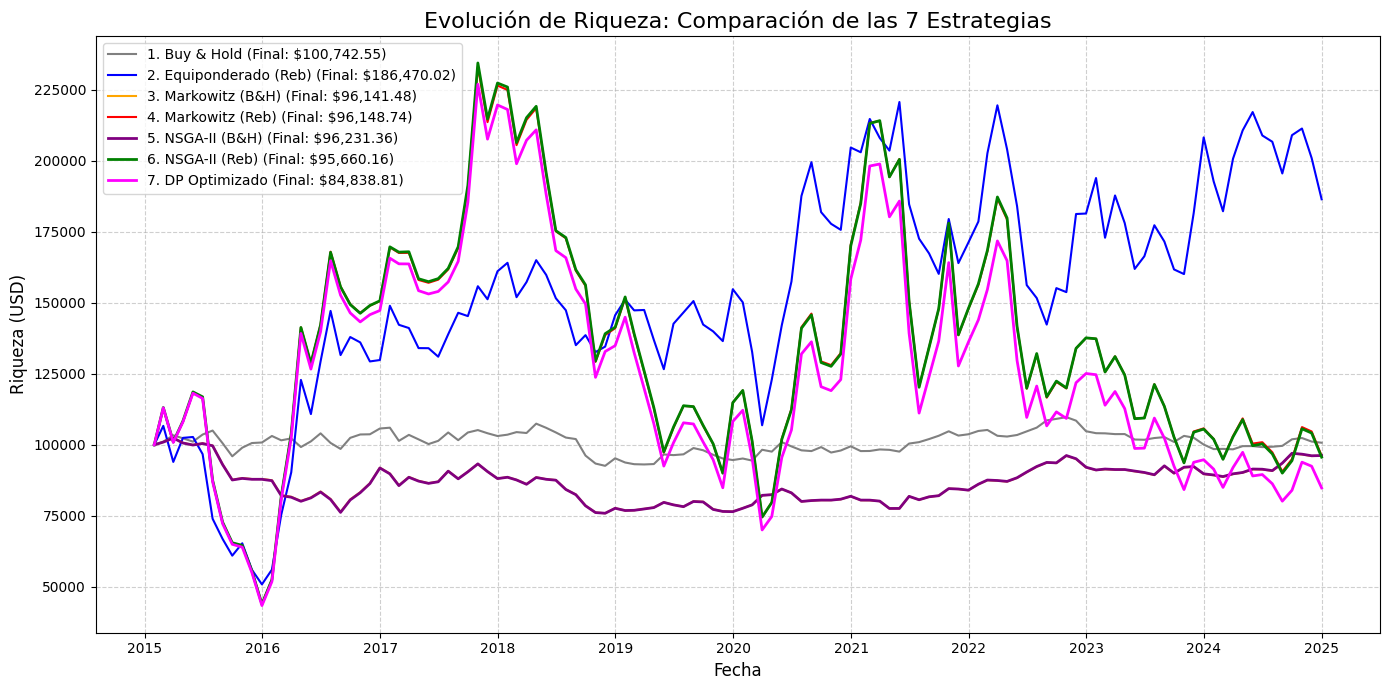

In [4]:
plt.figure(figsize=(14, 7))
colores = ['gray', 'blue', 'orange', 'red', 'purple', 'green', 'magenta']

for (nombre, riqueza), color in zip(curvas_riqueza.items(), colores):
    plt.plot(fechas, riqueza, label=f"{nombre} (Final: ${riqueza[-1]:,.2f})", color=color, linewidth=2 if 'DP' in nombre or 'NSGA' in nombre else 1.5)

plt.title('Evolución de Riqueza: Comparación de las 7 Estrategias', fontsize=16)
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Riqueza (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

## 4. Tabla Resumen y Ranking Automático

In [5]:
resultados_metricas = []

for nombre, riqueza in curvas_riqueza.items():
    ret_tot, sharpe, sortino, max_dd = calcular_metricas(riqueza)
    resultados_metricas.append({
        "Estrategia": nombre,
        "Riqueza Final ($)": round(riqueza[-1], 2),
        "Retorno Total (%)": round(ret_tot * 100, 2),
        "Sharpe Ratio": round(sharpe, 4),
        "Sortino Ratio": round(sortino, 4),
        "Max Drawdown (%)": round(max_dd * 100, 2)
    })

df_resumen = pd.DataFrame(resultados_metricas)

# Ranking Automático: Ordenar primariamente por Sharpe Ratio (Descendente) y Riqueza Final
df_ranking = df_resumen.sort_values(by=["Sharpe Ratio", "Riqueza Final ($)"], ascending=[False, False]).reset_index(drop=True)
df_ranking.index = df_ranking.index + 1
df_ranking.index.name = "Rank"

# Exportar para Streamlit (st.dataframe)
df_ranking.to_excel("ranking_estrategias.xlsx")
df_ranking

,Estrategia,Riqueza Final ($),Retorno Total (%),Sharpe Ratio,Sortino Ratio,Max Drawdown (%)
Rank,,,,,,
1,2. Equiponderado (Reb),186470.02,86.47,0.3492,0.7240,-52.32
2,4. Markowitz (Reb),96148.74,-3.85,0.2061,0.4001,-68.03
3,6. NSGA-II (Reb),95660.16,-4.34,0.2052,0.3980,-68.19
4,7. DP Optimizado,84838.81,-15.16,0.1786,0.3440,-69.14
5,1. Buy & Hold,100742.55,0.74,0.0436,0.0657,-13.82
6,5. NSGA-II (B&H),96231.36,-3.77,-0.0051,-0.0074,-25.86
7,3. Markowitz (B&H),96141.48,-3.86,-0.0064,-0.0093,-25.89


## 5. Gráficos de Barras Comparativos

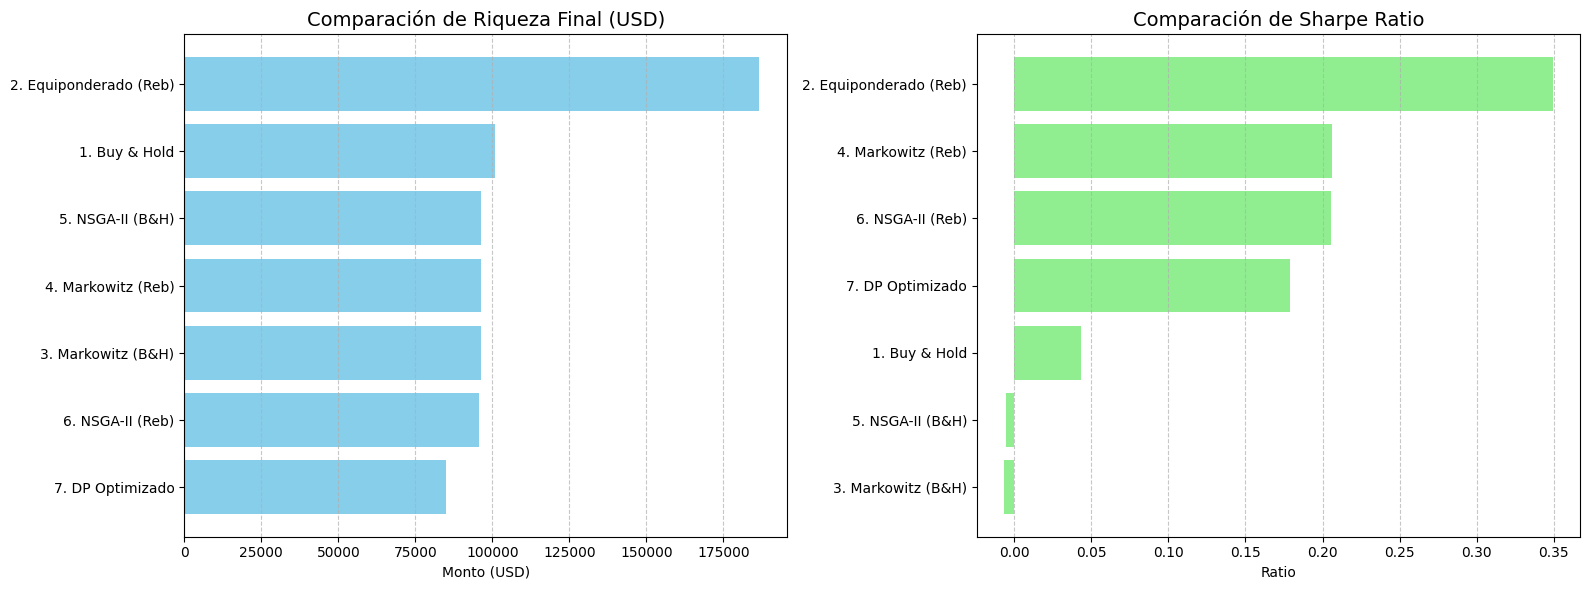

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Riqueza Final
df_resumen_sorted_wealth = df_resumen.sort_values(by="Riqueza Final ($)", ascending=True)
axes[0].barh(df_resumen_sorted_wealth["Estrategia"], df_resumen_sorted_wealth["Riqueza Final ($)"], color='skyblue')
axes[0].set_title('Comparación de Riqueza Final (USD)', fontsize=14)
axes[0].set_xlabel('Monto (USD)')
axes[0].grid(axis='x', linestyle='--', alpha=0.7)

# Gráfico 2: Sharpe Ratio
df_resumen_sorted_sharpe = df_resumen.sort_values(by="Sharpe Ratio", ascending=True)
axes[1].barh(df_resumen_sorted_sharpe["Estrategia"], df_resumen_sorted_sharpe["Sharpe Ratio"], color='lightgreen')
axes[1].set_title('Comparación de Sharpe Ratio', fontsize=14)
axes[1].set_xlabel('Ratio')
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()